In [1]:
import torch
import torch.nn.functional as F

from linear_with_fp8_cast import Fp8Linear

## Compare forward and backward passes

In [2]:
IN = 4096
OUT = 8192

# Fake data
batch_size = 2048
torch.manual_seed(0)
x = torch.randn(batch_size, IN, requires_grad=True, dtype=torch.bfloat16, device='cuda')
torch.manual_seed(0)
y = torch.randn(batch_size, IN, requires_grad=True, dtype=torch.bfloat16, device='cuda')

target = torch.randn(batch_size, OUT, dtype=torch.bfloat16, device='cuda')


# Initialize layers
linear_bf16 = torch.nn.Linear(IN, OUT, bias=False).to(torch.bfloat16)

linear_fp8 = Fp8Linear(IN, OUT, bias=False)
with torch.no_grad():
    linear_fp8.weight.copy_(linear_bf16.weight.data.detach().clone())

linear_bf16 = linear_bf16.cuda() 
linear_fp8 = linear_fp8.cuda()


# Run forward and Backward
output_bf16 = linear_bf16(x)
loss_bf16 = F.mse_loss(output_bf16, target)
loss_bf16.backward()

output_fp8 = linear_fp8(y)
loss_fp8 = F.mse_loss(output_fp8, target)
loss_fp8.backward()

In [ ]:
@torch.no_grad()
def calc_diff(x: torch.Tensor, y: torch.Tensor):
    """
    https://github.com/deepseek-ai/DeepGEMM/blob/main/deep_gemm/testing/numeric.py
    """
    x, y = x.double(), y.double()
    denominator = (x * x + y * y).sum()
    if denominator == 0:    # Which means that all elements in x and y are 0
        return 0.0
    sim = 2 * (x * y).sum() / denominator
    return 1 - sim


print("Output dist:", calc_diff(output_bf16, output_fp8))
print("Input grad dist:", calc_diff(x.grad, y.grad))
print("Weight grad dist:", calc_diff(linear_bf16.weight.grad, linear_fp8.weight.grad))

Output dist: tensor(0.0006, device='cuda:0', dtype=torch.float64)
Input grad dist: tensor(0.0007, device='cuda:0', dtype=torch.float64)
Weight grad dist: tensor(0.0008, device='cuda:0', dtype=torch.float64)


## Check for kernels was used

### fp32 with autocast to bf16

In [4]:
x = torch.randn(batch_size, IN, requires_grad=True, dtype=torch.float32, device='cuda')
linear = torch.nn.Linear(IN, OUT, bias=False).to(torch.float32).to("cuda")
target = torch.randn(batch_size, OUT, dtype=torch.float32, device='cuda')

with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA],
    record_shapes=True,
    with_stack=True
) as prof:
    with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
        y = linear(x)
        loss = F.mse_loss(y, target)
    loss.backward()

print(prof.key_averages().table(sort_by="self_cuda_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm         1.46%     104.748us         1.80%     129.414us      43.138us       4.582ms        75.87%       4.582ms       1.527ms             3  
void cutlass::Kernel2<cutlass_80_tensorop_bf16_s1681...         0.00%       0.000us         0.00%       0.000us       0.000us       1.681ms        27.83%       1.681ms       1.681ms             1  
void cutl

### Pure bf16

In [5]:
x = torch.randn(batch_size, IN, requires_grad=True, dtype=torch.bfloat16, device='cuda')
linear = torch.nn.Linear(IN, OUT, bias=False).to(torch.bfloat16).to("cuda")
target = torch.randn(batch_size, OUT, dtype=torch.bfloat16, device='cuda')

with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA],
    record_shapes=True,
    with_stack=True
) as prof:
    y = linear(x)
    loss = F.mse_loss(y, target)
    loss.backward()

print(prof.key_averages().table(sort_by="self_cuda_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm         1.75%     103.095us        22.68%       1.340ms     446.575us       4.554ms        94.31%       6.033ms       2.011ms             3  
void cutlass::Kernel2<cutlass_80_tensorop_bf16_s1681...         0.00%       0.000us         0.00%       0.000us       0.000us       1.669ms        34.56%       1.669ms       1.669ms             1  
         

### bf16 with fp8 kernels

In [6]:
x = torch.randn(batch_size, IN, requires_grad=True, dtype=torch.bfloat16, device='cuda')
target = torch.randn(batch_size, OUT, dtype=torch.bfloat16, device='cuda')

linear = torch.nn.Linear(IN, OUT, bias=False).to(torch.bfloat16)
linear_fp8 = Fp8Linear(IN, OUT, bias=False)
with torch.no_grad():
    linear_fp8.weight.copy_(linear_bf16.weight.data.detach().clone())
linear_fp8 = linear_fp8.to("cuda")

with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA],
    record_shapes=True,
    with_stack=True
) as prof:
    y = linear_fp8(x)
    loss = F.mse_loss(y, target)
    loss.backward()

print(prof.key_averages().table(sort_by="self_cuda_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                           kernel_scaled_matmul_fp8_fp8         0.00%       0.000us         0.00%       0.000us       0.000us       2.823ms        67.55%       2.823ms     941.080us             3  
                              Fp8LinearFunctionBackward         5.21%     294.194us        14.44%     815.006us     815.006us       2.001ms        47.88%       2.583ms       2.583ms             1  
         

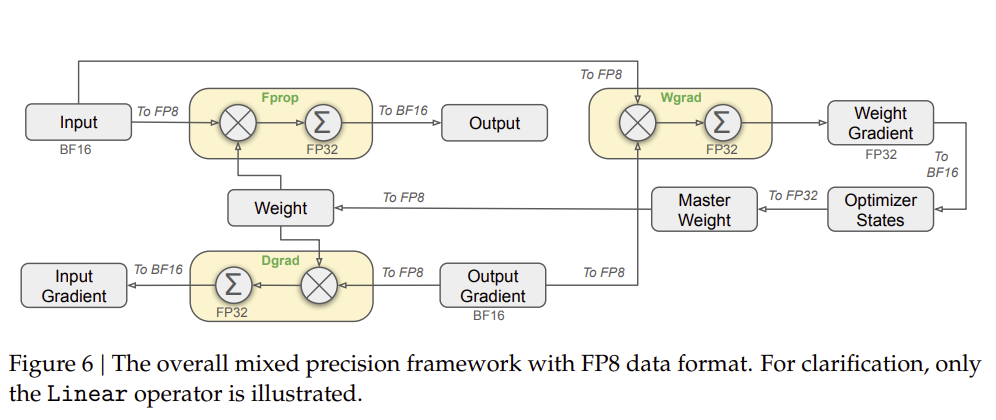